In [2]:
import numpy as np
def _bin_counts_around_stim(
    peaks_ms: dict[int, np.ndarray],
    bin_ms: float,
    stim_times_ms: np.ndarray,
    art_before_ms: float,
    art_after_ms: float,
    win_ms: tuple[float, float],
):
    """
    Bin spike counts around each stimulation event.
    """
    window_start_ms, window_end_ms = float(win_ms[0]), float(win_ms[1])

    if peaks_ms is None or len(peaks_ms) == 0:
        return None, None, None, 0

    stim_times_ms = np.asarray(stim_times_ms, float).ravel()
    if stim_times_ms.size == 0:
        return None, None, None, 0

    # Left/right edges & centers
    left_window_edges_ms: list[float] = []
    edge_value = -art_before_ms
    while edge_value >= window_start_ms:
        left_window_edges_ms.append(edge_value)
        edge_value -= bin_ms
    left_window_edges_ms = np.array(left_window_edges_ms[::-1])

    right_window_edges_ms: list[float] = []
    edge_value = art_after_ms
    while edge_value <= window_end_ms:
        right_window_edges_ms.append(edge_value)
        edge_value += bin_ms
    right_window_edges_ms = np.array(right_window_edges_ms)

    # Bin centers on each side
    left_bin_centers_ms  = (
        left_window_edges_ms[:-1] + 0.5 * bin_ms
        if left_window_edges_ms.size > 1 else np.array([], float)
    )
    right_bin_centers_ms = (
        right_window_edges_ms[:-1] + 0.5 * bin_ms
        if right_window_edges_ms.size > 1 else np.array([], float)
    )

    bin_edges_ms   = np.concatenate([left_window_edges_ms, right_window_edges_ms])
    bin_centers_ms = np.concatenate([left_bin_centers_ms, right_bin_centers_ms])
    n_bins         = bin_centers_ms.size

    # Number of bins on the left side (used to offset right-side indices)
    n_left_bins = max(left_window_edges_ms.size - 1, 0)

    n_trials    = len(stim_times_ms)
    ch_keys = sorted(peaks_ms.keys())
    n_channels = len(ch_keys)

    # counts[trial_index, channel_index, bin_index]
    counts = np.zeros((n_trials, n_channels, n_bins), float)

    # Binning
    for trial_index, stim_time_ms in enumerate(stim_times_ms):
        trial_window_start_ms = stim_time_ms + window_start_ms
        trial_window_end_ms   = stim_time_ms + window_end_ms
        for ch_i, ch_id in enumerate(ch_keys):
            spike_times_ms = np.asarray(peaks_ms[ch_id], float).ravel()
            if spike_times_ms.size == 0:
                continue

            # Spikes within the overall peri-stim window (absolute)
            in_window_mask = (
                (spike_times_ms >= trial_window_start_ms) &
                (spike_times_ms <= trial_window_end_ms)
            )
            if not in_window_mask.any():
                continue

            # Relative spike times in ms, centered at the stim
            spike_times_rel_ms = spike_times_ms[in_window_mask] - stim_time_ms

            # Exclude spikes in the artifact gap [-art_before_ms, +art_after_ms]
            left_side_mask  = (
                (spike_times_rel_ms >= window_start_ms) &
                (spike_times_rel_ms < -art_before_ms)
            )
            right_side_mask = (
                (spike_times_rel_ms > art_after_ms) &
                (spike_times_rel_ms <= window_end_ms)
            )

            # ---- LEFT side binning ----
            if left_window_edges_ms.size > 1 and left_side_mask.any():
                spike_times_left_ms = spike_times_rel_ms[left_side_mask]
                # Find bin index j such that edges[j] <= t < edges[j+1]
                left_bin_indices = np.searchsorted(
                    left_window_edges_ms, spike_times_left_ms, side="right"
                ) - 1
                valid_left_bins = (
                    (left_bin_indices >= 0) &
                    (left_bin_indices < left_window_edges_ms.size - 1)
                )
                if valid_left_bins.any():
                    np.add.at(counts[trial_index, ch_i], left_bin_indices[valid_left_bins], 1.0)

            # ---- RIGHT side binning ----
            if right_window_edges_ms.size > 1 and right_side_mask.any():
                spike_times_right_ms = spike_times_rel_ms[right_side_mask]
                right_bin_indices_local = np.searchsorted(
                    right_window_edges_ms, spike_times_right_ms, side="right"
                ) - 1
                valid_right_bins = (
                    (right_bin_indices_local >= 0) &
                    (right_bin_indices_local < right_window_edges_ms.size - 1)
                )
                if valid_right_bins.any():
                    # Map right-side bins into global bin indices
                    right_bin_indices_global = (
                        right_bin_indices_local[valid_right_bins] + n_left_bins
                    )
                    np.add.at(counts[trial_index, ch_i], right_bin_indices_global, 1.0)
    return counts, bin_centers_ms, bin_edges_ms, n_left_bins

def _smooth_segment(seg_counts, seg_edges, seg_centers, sigma_ms):
        """
        """
        L = seg_centers.size
        if L == 0 or sigma_ms <= 0:
            return seg_counts.copy()

        # bin widths
        dt_ms = np.diff(seg_edges)
        dt_sec = np.clip(dt_ms / 1000.0, 1e-12, None)

        # convert counts → rates
        rates = seg_counts / dt_sec[None, None, :]   # broadcast dt

        # Gaussian weights
        diff = seg_centers[:, None] - seg_centers[None, :]
        W = np.exp(-(diff**2) / (2.0 * sigma_ms**2))   # (L, L)

        # output
        out = np.full_like(rates, np.nan)

        for tr in range(rates.shape[0]):
            for ch in range(rates.shape[1]):
                r = rates[tr, ch]
                valid = np.isfinite(r)
                if not valid.any():
                    continue

                r_valid = np.where(valid, r, 0.0)
                num = r_valid @ W.T
                den = (valid.astype(float) @ W.T).clip(1e-12, None)
                out[tr, ch] = num / den

        return out

def _smooth_counts_gauss(
    counts: np.ndarray,
    edges: np.ndarray,
    bin_centers_ms: np.ndarray,
    sigma_ms: float,
    left_bins: int,
) -> np.ndarray:
    """
    Smooth spike counts -> firing rates (Hz) separately on left and right sides
    of the stim-blank gap, using a Gaussian in ms (NaN-aware at the per-bin level).
    """
    if counts is None or np.size(counts) == 0:
        return np.asarray(counts, float)

    gap_bin = int(left_bins)
    gap_bin = max(0, min(gap_bin, counts.shape[-1]))  # clamp

    left_counts   = counts[:, :, :gap_bin]
    right_counts  = counts[:, :, gap_bin:]
    left_centers  = bin_centers_ms[:gap_bin]
    right_centers = bin_centers_ms[gap_bin:]

    # edges is length (T+2): left edges (L+1) + right edges (R+1)
    left_edges  = edges[:gap_bin + 1]
    right_edges = edges[gap_bin + 1:]

    left_sm  = _smooth_segment(left_counts,  left_edges,  left_centers,  sigma_ms)
    right_sm = _smooth_segment(right_counts, right_edges, right_centers, sigma_ms)

    out = np.full_like(counts, np.nan, dtype=float)
    out[:, :, :gap_bin] = left_sm
    out[:, :, gap_bin:] = right_sm
    return out


0.0 338.76555633674235


/tmp/ipykernel_1057537/1526036700.py:34: RuntimeWarning: Mean of empty slice
  plt.plot(t_ms, np.nanmean(spikes[:, ch_select, :], axis = 0), color="red")


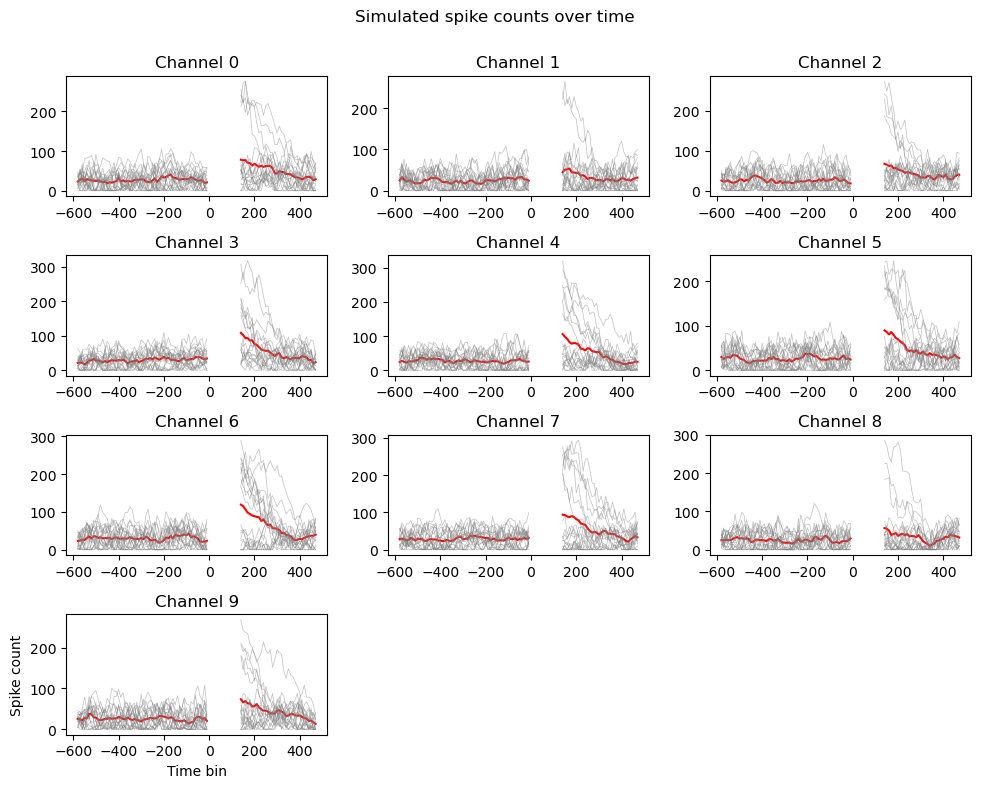

In [3]:
from wasabi.data_simulation import DataSimulation
import matplotlib.pyplot as plt
import numpy as np

n_trials = 20
n_ch = 128
n_bins = 106
n_stim = 32
onset_time = 58
stim_effect = 200
base_rate = 25
rw_sigma = 15
rate_max = 50
stim_dur_bins = 14

sim = DataSimulation(n_trials, n_ch, n_bins, n_stim, onset_time, stim_effect, base_rate, rw_sigma, rate_max, stim_dur_bins)

stim_mask = sim.generate_stim_trials()
rates = sim.generate_rates(add_stim=True)
spikes = sim.poisson_spikes(rates)

print(np.nanmin(rates), np.nanmax(rates))

bin_ms = 10
t_ms = (np.arange(n_bins) - onset_time) * bin_ms

plt.figure(figsize=(10, 8))
for ch_select in range(10):
    ax = plt.subplot(4, 3, ch_select + 1)

    # trials x time for this channel
    y = spikes[:, ch_select, :]  # (n_trials, n_bins)

    plt.plot(t_ms, np.nanmean(spikes[:, ch_select, :], axis = 0), color="red")
    plt.plot(t_ms, spikes[:, ch_select, :].T, color="gray", linewidth=0.5, alpha=0.5)

    plt.title(f"Channel {ch_select}")

plt.suptitle("Simulated spike counts over time\n")
plt.xlabel("Time bin")
plt.ylabel("Spike count")
plt.tight_layout()

In [27]:
import numpy as np

def simulate_perturbation(n_trial, n_ch, rank, n_stim, beta=1e-2,
    sigma2_latent=1.0,   # in Z = XW + eps
    sigma2_perturb=1.0,  # Lambda = Z D^T + eta
    w_dist = "uniform",
):
    rng = np.random.default_rng(0)

    D_true, _ = np.linalg.qr(rng.standard_normal((n_ch, rank))) # Use QR to get orthonormal basis for D
    if w_dist == "uniform":
        W_true = rng.uniform(low=-np.sqrt(3), high=np.sqrt(3), size=(rank, n_ch)) / np.sqrt(n_ch) # Scale so that E(WtW) is I
    elif w_dist == "normal":
        W_true = rng.standard_normal((rank, n_ch)) / np.sqrt(n_ch) # Scale so that E(WtW) is I
    else:
        raise ValueError(f"Invalid w_dist: {w_dist}")

    C_true = D_true @ W_true

    # Get stim vector
    X = np.zeros((n_ch, n_trial), dtype=float)
    for t in range(n_trial):
        idx = rng.choice(n_ch, size=n_stim, replace=False)
        X[idx, t] = 1.0

    # Generate noisy latents after stim
    eps = rng.standard_normal((rank, n_trial)) * np.sqrt(sigma2_latent)
    Z = W_true @ X + eps  # rank x n_trial

    # Observed response with noise
    perturb_true = D_true @ Z # n_ch x n_trial
    eta = rng.standard_normal(perturb_true.shape) * np.sqrt(sigma2_perturb)
    perturb = perturb_true + eta

    return X.T, perturb.T, D_true, W_true, C_true, Z.T, perturb_true.T

def sequential_lowrank_reconst_gt(
    X,
    perturb,
    train_idx,
    test_idx,
    rank,
    beta,
    start,
    pert_true,
):
    stim_train = X[train_idx]
    stim_test  = X[test_idx]
    pert_train = perturb[train_idx]
    # pert_test  = perturb[test_idx]
    pert_true = pert_true[test_idx]
    
    n_train, n_Ch = stim_train.shape
    I = np.eye(n_Ch)

    trial_list = []
    perturb_rel_err = []
    sign_acc_list = []

    XtX = np.zeros((n_Ch, n_Ch))

    for trial in range(start, n_train + 1):
        
        # Get basis from past data
        perturb_t = pert_train[:trial].T # channels x trials - transpose for SVD
        U_t, _, _ = np.linalg.svd(perturb_t, full_matrices=False)
        D_t = U_t[:, :rank]  # channels x rank, channel basis vectors

        # Project past response into latent space
        Z_t = D_t.T @ perturb_t # rank x nTrain

        # Use ridge fit just in case underdetermined to find optimized mapping to latents
        X_t = stim_train[:trial].T # channels x trials - transpose for SVD
        XtX = X_t @ X_t.T
        inv_term = beta * I + XtX
        W_lowrank = (Z_t @ X_t.T) @ np.linalg.inv(inv_term) # This gets the estimate of regularized low rank W
        
        # Predict perturb_test by projecting using W
        Z_test_hat = W_lowrank @ stim_test.T # rank x nTest
        pert_test_hat = D_t @ Z_test_hat # channels x nTest
        pert_test_hat = pert_test_hat.T # nTest x channels, transpose back to original shape

        # Relative RMSE, compare with GT
        err_fro = np.linalg.norm(pert_test_hat - pert_true, ord="fro")
        rel_err = err_fro / np.linalg.norm(pert_true, ord="fro")
        perturb_rel_err.append(rel_err)
        
        trial_list.append(trial)
        
        trial_sign_true = np.sign(np.mean(pert_true, axis=1))
        trial_sign_hat  = np.sign(np.mean(pert_test_hat, axis=1))
        trial_sign_acc = np.mean(trial_sign_true == trial_sign_hat)
        sign_acc_list.append(trial_sign_acc)
        
    perturb_rel_err = np.array(perturb_rel_err)
    return trial_list, perturb_rel_err, sign_acc_list, W_lowrank


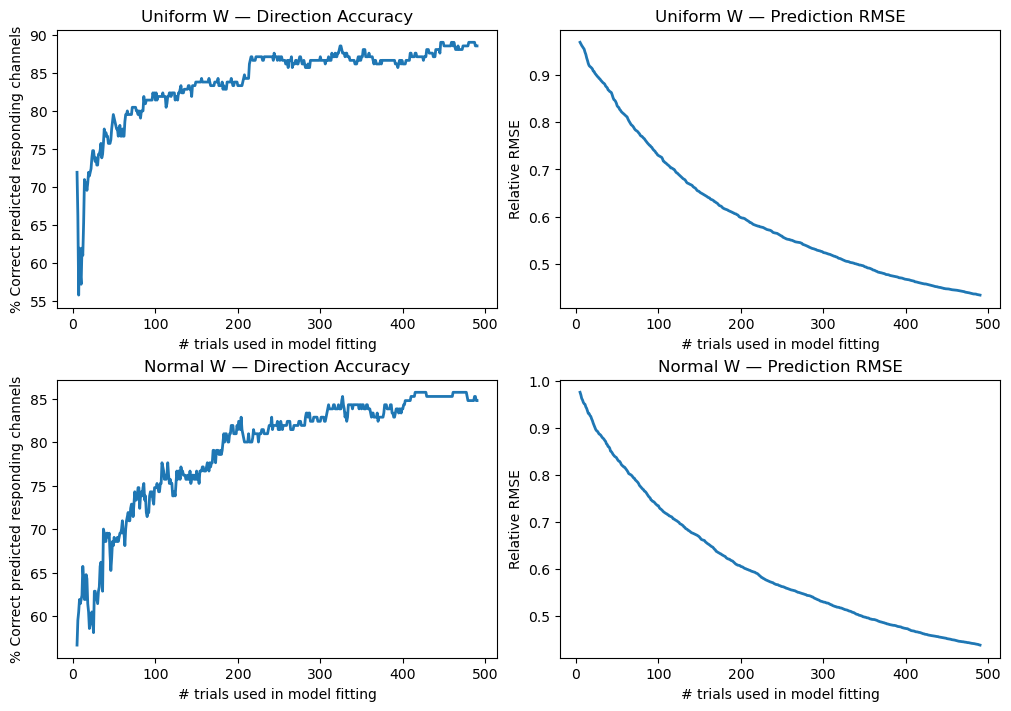

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import ShuffleSplit

# Stratify into train test across files
rs = ShuffleSplit(n_splits=1, test_size=0.3, random_state=0)

n_trial = 700
n_ch = 64
n_stim = 6
rank = 15
start = 5
beta = 20
sigma2_latent = 0.01
sigma2_perturb = 0.01


train_idx, test_idx = next(rs.split(np.zeros(n_trial)))

# Uniform
X_u, lam_obs_u, D_true_u, W_true_u, C_true_u, Z_u, pert_true_u = \
    simulate_perturbation(
        n_trial, n_ch, rank, n_stim, beta, sigma2_latent, sigma2_perturb, w_dist="uniform"
    )

trial_list_u, rel_err_u, sign_acc_u, W_lowrank_u = \
    sequential_lowrank_reconst_gt(
        X_u, lam_obs_u,
        train_idx, test_idx,
        rank, beta, start,
        pert_true_u
    )

# Normal
X_n, lam_obs_n, D_true_n, W_true_n, C_true_n, Z_n, pert_true_n = \
    simulate_perturbation(
        n_trial, n_ch, rank, n_stim, beta, sigma2_latent, sigma2_perturb, w_dist="normal"
    )

trial_list_n, rel_err_n, sign_acc_n, W_lowrank_n = \
    sequential_lowrank_reconst_gt(
        X_n, lam_obs_n,
        train_idx, test_idx,
        rank, beta, start,
        pert_true_n
    )

# Plotting
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),
    constrained_layout=True
)

# --- Uniform: sign accuracy ---
axes[0, 0].plot(trial_list_u, 100*np.asarray(sign_acc_u), lw=2)
axes[0, 0].set_title("Uniform W — Direction Accuracy")
axes[0, 0].set_xlabel("# trials used in model fitting")
axes[0, 0].set_ylabel("% Correct predicted responding channels")

# --- Uniform: RMSE ---
axes[0, 1].plot(trial_list_u, rel_err_u, lw=2)
axes[0, 1].set_title("Uniform W — Prediction RMSE")
axes[0, 1].set_xlabel("# trials used in model fitting")
axes[0, 1].set_ylabel("Relative RMSE")

# --- Normal: sign accuracy ---
axes[1, 0].plot(trial_list_n, 100*np.asarray(sign_acc_n), lw=2)
axes[1, 0].set_title("Normal W — Direction Accuracy")
axes[1, 0].set_xlabel("# trials used in model fitting")
axes[1, 0].set_ylabel("% Correct predicted responding channels")

# --- Normal: RMSE ---
axes[1, 1].plot(trial_list_n, rel_err_n, lw=2)
axes[1, 1].set_title("Normal W — Prediction RMSE")
axes[1, 1].set_xlabel("# trials used in model fitting")
axes[1, 1].set_ylabel("Relative RMSE")

plt.show()


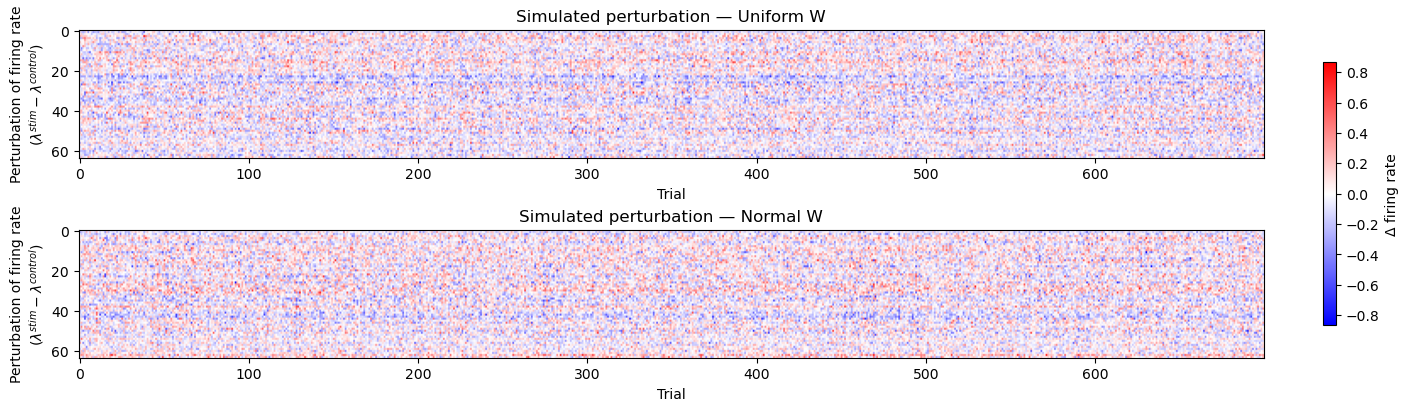

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 4),
    constrained_layout=True
)

# Shared color scale (important for comparison)
v = max(
    np.abs(lam_obs_u).max(),
    np.abs(lam_obs_n).max()
)

# --- Uniform ---
im0 = axes[0].imshow(
    lam_obs_u.T,
    aspect="auto",
    cmap="bwr",
    vmin=-v,
    vmax=v
)

axes[0].set_xlabel("Trial")
axes[0].set_ylabel(
    "Perturbation of firing rate\n"
    r"($\lambda^{stim}-\lambda^{control}$)"
)
axes[0].set_title("Simulated perturbation — Uniform W")

# --- Normal ---
im1 = axes[1].imshow(
    lam_obs_n.T,
    aspect="auto",
    cmap="bwr",
    vmin=-v,
    vmax=v
)

axes[1].set_xlabel("Trial")
axes[1].set_ylabel(
    "Perturbation of firing rate\n"
    r"($\lambda^{stim}-\lambda^{control}$)"
)
axes[1].set_title("Simulated perturbation — Normal W")

# Shared colorbar
fig.colorbar(im1, ax=axes, shrink=0.8, label="Δ firing rate")

plt.show()


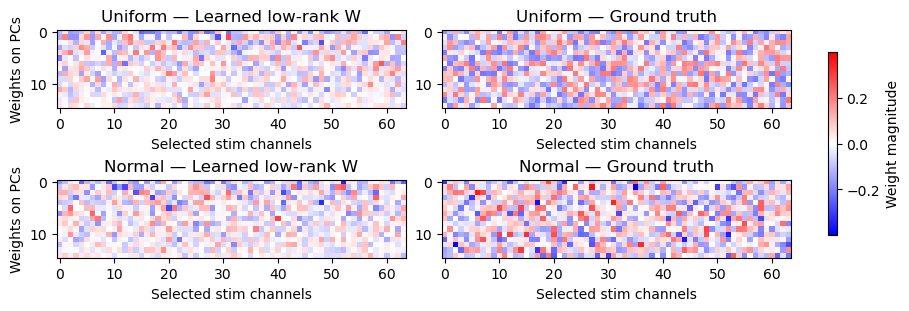

In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 3),
    constrained_layout=True
)

# Shared color scale (optional but recommended)
v = max(
    np.abs(W_lowrank_u).max(),
    np.abs(W_true_u).max(),
    np.abs(W_lowrank_n).max(),
    np.abs(W_true_n).max()
)

# Uniform
im0 = axes[0, 0].imshow(
    W_lowrank_u,
    aspect="auto",
    vmin=-v, vmax=v,
    cmap="bwr"
)
axes[0, 0].set_title("Uniform — Learned low-rank W")
axes[0, 0].set_xlabel("Selected stim channels")
axes[0, 0].set_ylabel("Weights on PCs")

im1 = axes[0, 1].imshow(
    W_true_u,
    aspect="auto",
    vmin=-v, vmax=v,
    cmap="bwr"
)
axes[0, 1].set_title("Uniform — Ground truth")
axes[0, 1].set_xlabel("Selected stim channels")

# Normal
im2 = axes[1, 0].imshow(
    W_lowrank_n,
    aspect="auto",
    vmin=-v, vmax=v,
    cmap="bwr"
)
axes[1, 0].set_title("Normal — Learned low-rank W")
axes[1, 0].set_xlabel("Selected stim channels")
axes[1, 0].set_ylabel("Weights on PCs")

im3 = axes[1, 1].imshow(
    W_true_n,
    aspect="auto",
    vmin=-v, vmax=v,
    cmap="bwr"
)
axes[1, 1].set_title("Normal — Ground truth")
axes[1, 1].set_xlabel("Selected stim channels")

# Shared colorbar
fig.colorbar(im3, ax=axes, shrink=0.8, label="Weight magnitude")

plt.show()
